# Mobile App Market Research

### 🎯 Goal
Analyze behavioral data from a mobile game to evaluate user retention, assess A/B test results, and define relevant metrics for in-game event evaluation.

### ✅ Objectives
1. **Retention Analysis:**  
   Calculate the daily retention rate of players from their registration date. Develop a flexible Python function that works efficiently on both full and sampled datasets.
2. **A/B Test Evaluation:**  
   Compare promotional offer performance using key revenue metrics (ARPU, conversion rate). Determine whether the test group’s uplift is statistically and practically significant.
3. **Event Performance Metrics:**  
   Define KPIs to assess the success of the "Plants & Gardens" in-game event, considering both standard and penalty-based variations. Focus on engagement, reward acquisition, and user progression.

In [172]:
# Import the necessary libraries
import re
from urllib.parse import urlencode
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

%matplotlib inline

## Task 1 - Retention Analysis

**Calculate the daily retention rate of players from their registration date. Develop a flexible Python function that works efficiently on both full and sampled datasets.**

**Approach:**
1.	Load and validate the data
    - Import and inspect reg_data.csv (registration timestamps) and auth_data.csv (login activity).
	- Check for missing or duplicate user IDs, validate timestamp formats.
2.	Calculate retention
	- Merge registration and login datasets on uid.
	- Assign each user to a cohort based on their registration date.
	- Compute the number of days since registration for each login event.
	- Aggregate and normalize logins per cohort-day to calculate retention rates.
	- Visualize results as a pivot table or heatmap.
3.	Write a function
	- Encapsulate the above logic into a reusable Python function.
	- Allow parameters like cohort granularity or date range filtering.

### 1. Data Loading and Validation

In [173]:
# Define a function for loading files using Google Drive
def gdrive_download(url: str):
    """
     Downloads a file from a public Google Drive link using gdown and saves it.
    """
    match = re.search(r'/d/([a-zA-Z0-9_-]+)', url)
    if not match:
        raise ValueError("Unable to extract file_id from the URL. Make sure it follows the format /file/d/FILE_ID/")
    
    file_id = match.group(1)

    return gdown.download(id=file_id, quiet=False, use_cookies=False, fuzzy=True)

In [174]:
# Prepare links for the files to be analyzed
reg_url = gdrive_download('https://drive.google.com/file/d/1nx3FnrR40w7tySetvM9r-l8ts84bFrjx')
auth_url = gdrive_download('https://drive.google.com/file/d/1Rp_m650usbFrpotxDoIajzmxzzUr2A79')

Downloading...
From: https://drive.google.com/uc?id=1nx3FnrR40w7tySetvM9r-l8ts84bFrjx
To: /Users/user/Documents/projects/mobile_app_analysis/reg_data.csv
100%|██████████| 18.0M/18.0M [00:03<00:00, 4.91MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1Rp_m650usbFrpotxDoIajzmxzzUr2A79
From (redirected): https://drive.google.com/uc?id=1Rp_m650usbFrpotxDoIajzmxzzUr2A79&confirm=t&uuid=5cb52fe1-9a2e-487a-b23b-67127af4695a
To: /Users/user/Documents/projects/mobile_app_analysis/auth_data.csv
100%|██████████| 170M/170M [00:35<00:00, 4.74MB/s] 


In [175]:
# Read all data from the files and store them in DataFrames
reg_data = pd.read_csv(reg_url, sep=';')
auth_data = pd.read_csv(auth_url, sep=';')


In [176]:
# Preview the registration data DataFrame
reg_data.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


In [177]:
# Convert the date column to datetime format
reg_data['reg_ts'] = pd.to_datetime(reg_data['reg_ts'], unit='s')

In [178]:
# Check the date conversion in the registration DataFrame
reg_data.head()

,reg_ts,uid
0,1998-11-18 09:43:43,1
1,1999-07-22 22:38:09,2
2,2000-01-13 22:27:27,3
3,2000-05-28 14:19:01,4
4,2000-09-16 11:21:53,5


In [179]:
# Display information about the DataFrame
reg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   reg_ts  1000000 non-null  datetime64[ns]
 1   uid     1000000 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 15.3 MB


In [180]:
# View descriptive statistics of the data
reg_data.describe()

,reg_ts,uid
count,1000000,1.000000e+06
mean,2019-01-24 12:12:34.523666688,5.552354e+05
min,1998-11-18 09:43:43,1.000000e+00
25%,2018-06-03 13:55:11.500000,2.776438e+05
50%,2019-07-30 02:35:25,5.550455e+05
75%,2020-04-01 16:28:40.500000,8.329712e+05
max,2020-09-23 15:17:24,1.110622e+06
std,NaN,3.206011e+05


In [181]:
# Count the number of unique values
reg_data.nunique()

reg_ts    1000000
uid       1000000
dtype: int64

**`reg_data` overview:**

- `reg_ts`: registration date, converted to `datetime64[ns]`  
- `uid`: unique user identifier in `int64` format  
- Total number of unique records: **1 000 000** → this represents the total number of registered users  
- No missing values in the DataFrame  
- First registration date: **1998-11-18 09:43:43**  
- Last registration date: **2020-09-23 15:17:24**  
- **Over 50%** of registrations were completed within the last year

In [182]:
# Preview the loaded authorization data
auth_data.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


In [183]:
# Convert the date column to datetime format
auth_data['auth_ts'] = pd.to_datetime(auth_data['auth_ts'], unit='s')

In [184]:
# Check the result of the date conversion
auth_data.head()

,auth_ts,uid
0,1998-11-18 09:43:43,1
1,1999-07-22 22:38:09,2
2,1999-07-25 16:46:46,2
3,1999-07-31 03:50:15,2
4,1999-08-05 17:49:39,2


In [185]:
# Display information about the DataFrame
auth_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype         
---  ------   -----         
 0   auth_ts  datetime64[ns]
 1   uid      int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 146.5 MB


In [186]:
# Since the DataFrame is very large, the info() method cannot reliably detect missing values
# Check for missing values separately
auth_data.isnull().sum()

auth_ts    0
uid        0
dtype: int64

In [187]:
# View descriptive statistics of the data
auth_data.describe()

,auth_ts,uid
count,9601013,9.601013e+06
mean,2019-01-29 16:12:06.254851584,3.347198e+05
min,1998-11-18 09:43:43,1.000000e+00
25%,2018-06-07 12:40:47,9.599700e+04
50%,2019-07-31 12:43:16,2.579210e+05
75%,2020-04-02 10:25:21,5.190250e+05
max,2020-09-23 15:17:24,1.110622e+06
std,NaN,2.832669e+05


In [188]:
# Count the number of unique values
auth_data.nunique()

auth_ts    9180915
uid        1000000
dtype: int64

**`auth_data` overview:**

- `auth_ts`: authorization date, converted to `datetime64[ns]`  
- `uid`: unique user identifier in `int64` format  
- Total number of authorizations: **9,180,915**  
- The number of unique users matches the number in `reg_data`  
- No missing values in the DataFrame  
- First authorization date: **1998-11-18 09:43:43**  
- Last authorization date: **2020-09-23 15:17:24**  
- **Over 50%** of registrations occurred within the last year

### 2. Retention Calculation

Retention - один из самых важных показателей в компании. Ваша задача - написать функцию, которая будет считать retention игроков (по дням от даты регистрации игрока).


Retention is one of the most important metrics for a company.  
Your task is to write a function that calculates user retention (by days since the user's registration date).

In [189]:
# Merge the DataFrames; use a left join on the registration table 
# since it represents the user's first touchpoint with the application
app_data = pd.merge(reg_data, auth_data, how='left', on='uid')
app_data.head()

,reg_ts,uid,auth_ts
0,1998-11-18 09:43:43,1,1998-11-18 09:43:43
1,1999-07-22 22:38:09,2,1999-07-22 22:38:09
2,1999-07-22 22:38:09,2,1999-07-25 16:46:46
3,1999-07-22 22:38:09,2,1999-07-31 03:50:15
4,1999-07-22 22:38:09,2,1999-08-05 17:49:39


In [190]:
# Check the shape of the DataFrame
app_data.shape

(9601013, 3)

Объединение таблиц прошло успешно. Общее количество строк равно 9601013, что соответствует общему количество авторизаций в таблице `auth_data`

In [191]:
# Add columns converting timestamps to daily periods for further grouping
app_data['reg_date'] = app_data['reg_ts'].dt.to_period('D')
app_data['auth_date'] = app_data['auth_ts'].dt.to_period('D')

In [192]:
# Verify the addition of new columns
app_data.head()

,reg_ts,uid,auth_ts,reg_date,auth_date
0,1998-11-18 09:43:43,1,1998-11-18 09:43:43,1998-11-18,1998-11-18
1,1999-07-22 22:38:09,2,1999-07-22 22:38:09,1999-07-22,1999-07-22
2,1999-07-22 22:38:09,2,1999-07-25 16:46:46,1999-07-22,1999-07-25
3,1999-07-22 22:38:09,2,1999-07-31 03:50:15,1999-07-22,1999-07-31
4,1999-07-22 22:38:09,2,1999-08-05 17:49:39,1999-07-22,1999-08-05


In [193]:
# Registration date will be the basis for cohort assignment
# Define new variables
start_date = pd.Period('2020-05-01', freq='D')
end_date = pd.Period('2020-05-10', freq='D')

In [194]:
# Filter the DataFrame using the defined date range
app_data = app_data[(app_data['reg_date'] >= start_date) & (app_data['auth_date'] <= end_date)]
app_data.head()

,reg_ts,uid,auth_ts,reg_date,auth_date
9009122,2020-05-01 00:01:00,874066,2020-05-01 00:01:00,2020-05-01,2020-05-01
9009123,2020-05-01 00:02:07,874067,2020-05-01 00:02:07,2020-05-01,2020-05-01
9009124,2020-05-01 00:03:14,874068,2020-05-01 00:03:14,2020-05-01,2020-05-01
9009125,2020-05-01 00:03:14,874068,2020-05-03 15:44:00,2020-05-01,2020-05-03
9009126,2020-05-01 00:03:14,874068,2020-05-09 06:30:24,2020-05-01,2020-05-09


In [195]:
# Calculate the number of days between registration and authentication
app_data['visit_dif'] = (app_data['auth_date'] - app_data['reg_date']).apply(lambda x: x.n)
app_data.head()

,reg_ts,uid,auth_ts,reg_date,auth_date,visit_dif
9009122,2020-05-01 00:01:00,874066,2020-05-01 00:01:00,2020-05-01,2020-05-01,0
9009123,2020-05-01 00:02:07,874067,2020-05-01 00:02:07,2020-05-01,2020-05-01,0
9009124,2020-05-01 00:03:14,874068,2020-05-01 00:03:14,2020-05-01,2020-05-01,0
9009125,2020-05-01 00:03:14,874068,2020-05-03 15:44:00,2020-05-01,2020-05-03,2
9009126,2020-05-01 00:03:14,874068,2020-05-09 06:30:24,2020-05-01,2020-05-09,8


In [196]:
# Group the data by cohort and day difference (index)
app_cohort = app_data \
    .groupby(['reg_date', 'visit_dif']) \
    .agg({'uid': 'count'}) \
    .rename(columns={'uid': 'users'}) \
    .sort_values(by='reg_date')

In [197]:
# Calculate retention and store it in a new column
app_cohort['retention'] = app_cohort['users'] / app_cohort.groupby(['reg_date'])['users'].transform('max')
app_cohort.head()

users  retention
reg_date   visit_dif                  
2020-05-01 0           1295   1.000000
           1             20   0.015444
           2             51   0.039382
           3             59   0.045560
           4             64   0.049421

In [198]:
# Add cohort size for better visualization
app_cohort['size'] = app_cohort.groupby(['reg_date'])['users'].transform('max')
app_cohort.head()

users  retention  size
reg_date   visit_dif                        
2020-05-01 0           1295   1.000000  1295
           1             20   0.015444  1295
           2             51   0.039382  1295
           3             59   0.045560  1295
           4             64   0.049421  1295

In [199]:
# Create a pivot table from the DataFrame
app_cohort_pivot = app_cohort.pivot_table(index=['reg_date', 'size'], columns='visit_dif', values='retention')
app_cohort_pivot = app_cohort_pivot.loc[:, app_cohort_pivot.columns != 0]

# Apply styles for better readability
styled_pivot = (app_cohort_pivot
                .style
                .set_caption('User Retention by Day')
                .background_gradient(cmap='plasma', axis=0)
                .highlight_null('white')
                .format("{:.2%}", na_rep="")
                .set_table_styles([
                    {'selector': 'th', 'props': [('min-width', '50px')]},
                    {'selector': 'tr:hover', 'props': [('background-color', '#ffff99')]},
                ]))
styled_pivot

,visit_dif,1,2,3,4,5,6,7,8,9
reg_date,size,,,,,,,,,
2020-05-01,1295,1.54%,3.94%,4.56%,4.94%,6.02%,7.57%,6.02%,4.63%,4.63%
2020-05-02,1297,1.54%,4.47%,3.70%,5.55%,6.32%,6.25%,5.55%,5.32%,
2020-05-03,1300,1.46%,4.85%,4.23%,5.54%,5.23%,7.08%,6.62%,,
2020-05-04,1301,2.46%,3.61%,4.77%,5.92%,6.69%,7.46%,,,
2020-05-05,1304,0.92%,4.37%,4.06%,4.06%,5.98%,,,,
2020-05-06,1306,2.37%,4.29%,4.98%,4.29%,,,,,
2020-05-07,1308,2.22%,4.66%,4.59%,,,,,,
2020-05-08,1310,1.76%,4.27%,,,,,,,
2020-05-09,1313,2.51%,,,,,,,,


#### Intermediate Summary: Retention by Day

We successfully calculated and visualized daily user retention by cohort.  
The heatmap above shows how many users returned on each day after registration, normalized by cohort size.

This allows us to:
- Identify drop-off patterns early in the user lifecycle
- Compare different cohorts by engagement behavior
- Establish a baseline for future experiments or product changes

Having validated the logic and results, we can now move on to generalizing this analysis into a reusable function.

### 3. Function Implementation

Now that the retention logic is tested and visualized, we’ve wrapped it into a reusable function: `retention()`.

This function:
- Takes two datasets: one with user registrations, and one with logins
- Filters data based on the selected date range
- Calculates daily retention by user cohort (registration date)
- Allows you to limit the number of days shown (`max_days`)
- Returns a formatted pivot table with retention values
- Supports color normalization in the heatmap (by row or by column)

This makes it easy to repeat the analysis, adjust parameters, and reuse the logic for different time periods or user segments.

In [200]:
def retention(registration_data, authentication_data, start_date, end_date, max_days=None, normalize_axis='columns'):
    """
    Returns a pivot table with user retention over a given period.

    Parameters:
        registration_data (DataFrame): User registration data.  
            Expected columns:  
                - uid (str): Unique user identifier  
                - reg_ts (int): Registration time in Unix timestamp

        authentication_data (DataFrame): User authentication data.  
            Expected columns:  
                - uid (str): Unique user identifier  
                - auth_ts (int): Authentication time in Unix timestamp

        start_date (str): Start of the analysis period, in 'YYYY-MM-DD' format  
        end_date (str): End of the analysis period, in 'YYYY-MM-DD' format  
        max_days (int, optional): Maximum number of days to include in retention calculation (default is None)  
        normalize_axis (str): Axis to normalize color gradients:
            - 'columns' (default): normalize across columns
            - 'index': normalize across rows

    Returns:
        Styler: A styled pivot table with daily retention rates for each cohort
    """
    # Convert registration and authentication timestamps to datetime
    registration_data['reg_ts'] = pd.to_datetime(registration_data['reg_ts'], unit='s')
    authentication_data['auth_ts'] = pd.to_datetime(authentication_data['auth_ts'], unit='s')
    
    # Merge registration and authentication data on uid
    app_data = pd.merge(registration_data, authentication_data, how='left', on='uid')
    
    # Create period columns (by day) for cohort and activity date
    app_data['reg_date'] = app_data['reg_ts'].dt.to_period('D')
    app_data['auth_date'] = app_data['auth_ts'].dt.to_period('D')
    
    # Filter data by the specified date range
    start = pd.Period(start_date, freq='D')
    end = pd.Period(end_date, freq='D')
    app_data = app_data[(app_data['reg_date'] >= start) & (app_data['auth_date'] <= end)]

    # Calculate the number of days between registration and authentication
    app_data['visit_dif'] = (app_data['auth_date'] - app_data['reg_date']).apply(lambda x: x.n)

    # Filter by day limit for retention calculation
    if max_days is not None:
        app_data = app_data[app_data['visit_dif'] <= max_days]

    # Group data by cohort (registration date) and day offset since registration
    app_cohort = app_data \
        .groupby(['reg_date', 'visit_dif']) \
        .agg({'uid': 'count'}) \
        .rename(columns={'uid': 'users'}) \
        .sort_values(by='reg_date')
    
    # Calculate retention and store in a new column
    app_cohort['retention'] = app_cohort['users'] / app_cohort.groupby(['reg_date'])['users'].transform('max')

    # Add cohort size for better readability
    app_cohort['size'] = app_cohort.groupby(['reg_date'])['users'].transform('max')

    # Create a pivot table from the cohort data
    app_cohort_pivot = app_cohort.pivot_table(index=['reg_date', 'size'], columns='visit_dif', values='retention')

    # Remove day 0 (authentication on registration day) — retention is always 100% there
    app_cohort_pivot = app_cohort_pivot.loc[:, app_cohort_pivot.columns != 0]

    # Drop rows with all missing values
    app_cohort_pivot = app_cohort_pivot.dropna(how='all', axis=0)

    # Apply styling for better readability
    styled_pivot = (app_cohort_pivot
                    .style
                    .set_caption('User Retention by Day')
                    .background_gradient(cmap='plasma', axis=normalize_axis)
                    .highlight_null('white')
                    .format("{:.2%}", na_rep="")
                    .set_table_styles([
                        {'selector': 'th', 'props': [('min-width', '50px')]},
                        {'selector': 'tr:hover', 'props': [('background-color', '#ffff99')]},
                    ]))

    return styled_pivot

In [201]:
# Run a test of the retention function
retention(reg_data, auth_data, '2020-09-01', '2020-09-20', 14, 'columns')

,visit_dif,1,2,3,4,5,6,7,8,9,10,11,12,13,14
reg_date,size,,,,,,,,,,,,,,
2020-09-01,1586,2.02%,4.10%,4.22%,4.60%,6.43%,5.61%,6.43%,4.10%,5.42%,5.11%,5.36%,4.85%,5.49%,4.29%
2020-09-02,1588,2.52%,3.90%,4.66%,5.67%,6.23%,7.12%,6.30%,4.85%,4.09%,5.67%,5.48%,5.48%,4.35%,4.97%
2020-09-03,1591,2.33%,5.41%,4.71%,6.54%,6.98%,8.55%,6.35%,5.47%,6.29%,6.35%,5.53%,5.85%,5.97%,5.47%
2020-09-04,1593,2.01%,3.64%,3.64%,5.15%,6.40%,7.28%,4.96%,5.34%,4.33%,5.65%,5.52%,4.33%,5.59%,4.39%
2020-09-05,1596,2.76%,3.95%,4.64%,5.45%,5.89%,7.46%,4.89%,5.08%,5.45%,6.02%,5.20%,4.57%,5.39%,4.51%
2020-09-06,1599,3.13%,4.32%,5.44%,5.63%,5.88%,6.82%,6.07%,5.82%,5.50%,4.88%,4.75%,5.38%,5.19%,5.50%
2020-09-07,1601,2.94%,4.25%,5.37%,5.06%,6.37%,7.31%,5.25%,4.12%,5.62%,6.00%,5.68%,4.56%,5.06%,
2020-09-08,1604,1.75%,3.93%,3.93%,4.86%,7.61%,7.54%,6.61%,5.17%,5.17%,6.55%,5.36%,5.92%,,
2020-09-09,1607,1.74%,3.24%,4.67%,5.72%,6.66%,5.72%,5.91%,4.36%,5.04%,3.73%,5.04%,,,


#### Retention Analysis Results

- Daily cohort-based retention rates were calculated based on registration date.  
- A pivot table was built to show the share of users who returned within 14 days after registration.  
- A flexible `retention()` function was implemented, which allows:
  - specifying custom analysis date ranges;
  - limiting the retention window (e.g., D14);
  - controlling the axis for color normalization in visual output.  
- The function returns a styled table suitable for exploring user engagement patterns.

**Key Insights:**
1. **Day 1 retention averages around ~2%**, indicating a high churn rate immediately after installation.  
2. **A second spike in retention appears on Day 6** (up to 7-8%), possibly triggered by in-game mechanics or scheduled notifications.  
3. **Subsequent retention declines gradually**, which may reflect a small but steady core audience.

## Task 2 - A/B Test Evaluation
**Compare promotional offer performance using key revenue metrics (ARPU, conversion rate). Determine whether the test group’s uplift is statistically and practically significant.**

**Context:**  
As part of the experiment, users were split into two groups, each shown a different set of promotions. The following is known:
- The ARPU in the test group is 5% higher than in the control group.
- The control group has 1,928 paying users out of 202,103 total.
- The test group has 1,805 paying users out of 202,667 total.

**Key questions:**  
- Which promotional set performed better?  
- Which metrics should be compared: ARPU, ARPPU, Conversion Rate?  
- Should statistical significance tests be applied — and if so, which ones?

**Approach:**
1. Load and validate the data  
2. Compare reported figures with actual values from the dataset  
3. Calculate core metrics: ARPU, ARPPU, Conversion Rate  
4. If necessary, apply statistical tests (e.g., z-test, bootstrapping)  
5. Draw a conclusion and determine which promotion is more effective

### 1. Data Loading and Validation

In [202]:
# Prepare the link to the A/B test dataset
ab_data_url = gdrive_download('https://drive.google.com/file/d/1PfGlnjL1RhRJ3UN7jUtOzjnN516oRCCD')

Downloading...
From: https://drive.google.com/uc?id=1PfGlnjL1RhRJ3UN7jUtOzjnN516oRCCD
To: /Users/user/Documents/projects/mobile_app_analysis/ab_test.csv
100%|██████████| 4.35M/4.35M [00:00<00:00, 5.82MB/s]


In [203]:
# Read the data from the file and store it in a DataFrame
ab_data = pd.read_csv(ab_data_url, sep=';')
ab_data.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [204]:
# View DataFrame information
ab_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404770 entries, 0 to 404769
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    404770 non-null  int64 
 1   revenue    404770 non-null  int64 
 2   testgroup  404770 non-null  object
dtypes: int64(2), object(1)
memory usage: 9.3+ MB


In [205]:
# Count the number of unique values
ab_data.nunique()

user_id      404770
revenue        1477
testgroup         2
dtype: int64

In [206]:
# View descriptive statistics of the data
ab_data.describe()

,user_id,revenue
count,404770.000000,404770.000000
mean,202385.500000,26.083435
std,116847.178567,681.652928
min,1.000000,0.000000
25%,101193.250000,0.000000
50%,202385.500000,0.000000
75%,303577.750000,0.000000
max,404770.000000,37433.000000


We can observe a significant skew in the revenue distribution, most likely caused by a large number of users with zero revenue.  
To illustrate this, we will plot the distribution.

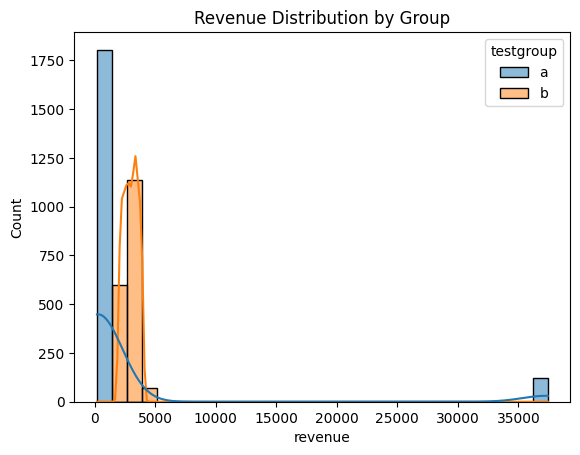

In [207]:
# Plot histograms of revenue distribution by group (excluding zero revenue)
sns.histplot(data=ab_data[ab_data.revenue > 0], x='revenue', hue='testgroup', kde=True, bins=30)
plt.title('Revenue Distribution by Group');

In group A, we observe a right-tail outlier that significantly skews the descriptive statistics of the dataset.

Let’s take a closer look at the revenue distribution by group.

In [208]:
# Create separate DataFrames for each group
a_data = ab_data[ab_data.testgroup == 'a']
b_data = ab_data[ab_data.testgroup == 'b']

In [209]:
# View descriptive statistics for group A
a_data.describe()

,user_id,revenue
count,202103.000000,202103.000000
mean,202555.909843,25.413720
std,116802.329266,920.768137
min,2.000000,0.000000
25%,101502.500000,0.000000
50%,202988.000000,0.000000
75%,303559.000000,0.000000
max,404769.000000,37433.000000


In [210]:
# View descriptive statistics for group A (only users with revenue > 0)
a_data[a_data['revenue'] > 0].describe()

,user_id,revenue
count,1928.000000,1928.000000
mean,200152.677905,2663.998444
std,116596.504905,9049.039763
min,73.000000,200.000000
25%,99323.000000,257.000000
50%,199854.500000,311.000000
75%,299664.250000,361.000000
max,404768.000000,37433.000000


In [211]:
# View descriptive statistics for group A (users with revenue > 0 and < 30,000)
a_data[(a_data.revenue > 0) & (a_data.revenue < 30000)].describe()

,user_id,revenue
count,1805.000000,1805.000000
mean,199923.686981,302.458172
std,116615.234772,57.914246
min,73.000000,200.000000
25%,98963.000000,254.000000
50%,199268.000000,305.000000
75%,298918.000000,352.000000
max,404768.000000,400.000000


In [212]:
# View descriptive statistics for group A (users with revenue > 30,000)
a_data[(a_data.revenue > 30000)].describe()

,user_id,revenue
count,123.000000,123.000000
mean,203513.073171,37319.121951
std,116745.137742,25.442183
min,417.000000,37293.000000
25%,109013.500000,37301.000000
50%,204560.000000,37311.000000
75%,317108.500000,37329.000000
max,399295.000000,37433.000000


In [213]:
# Calculate total revenue for group A excluding values greater than 30,000
a_data[(a_data.revenue < 30000)]['revenue'].sum()

np.int64(545937)

In [214]:
# Calculate total revenue for group A from users with revenue ≥ 30,000
a_data[(a_data.revenue >= 30000)]['revenue'].sum()

np.int64(4590252)

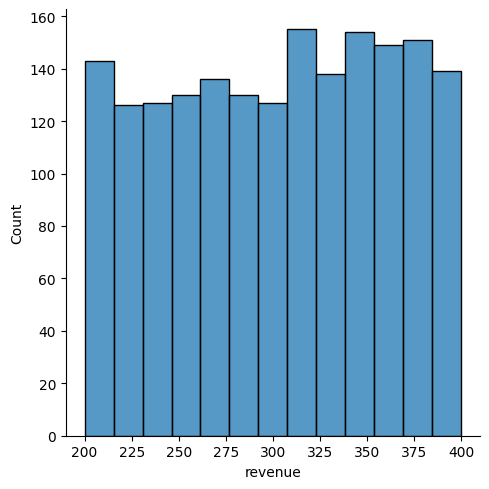

In [215]:
# Visualize the left side of the revenue distribution for group A
sns.displot(a_data[(a_data.revenue > 0) & (a_data.revenue < 30000)], x='revenue');

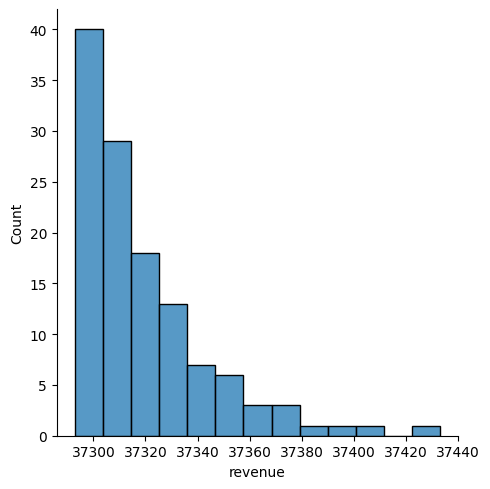

In [216]:
# Visualize the right side of the revenue distribution for group A
sns.displot(a_data[a_data.revenue > 30000], x='revenue');

In [217]:
# View descriptive statistics for group B (only users with revenue > 0)
b_data[b_data['revenue'] > 0].describe()

,user_id,revenue
count,1805.000000,1805.000000
mean,205834.548476,3003.658172
std,116400.045485,572.619709
min,161.000000,2000.000000
25%,106815.000000,2513.000000
50%,206651.000000,3022.000000
75%,304907.000000,3478.000000
max,404526.000000,4000.000000


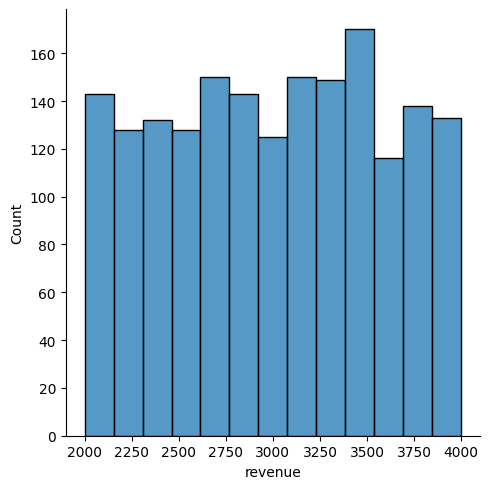

In [218]:
# Visualize the revenue distribution for group B
sns.displot(b_data[b_data.revenue > 0], x='revenue');

In [219]:
# Filter out outliers from group A
filtered_a_data = a_data[a_data['revenue'] <= 30000]
filtered_a_data.head()

,user_id,revenue,testgroup
1,2,0,a
2,3,0,a
9,10,0,a
10,11,0,a
11,12,0,a


In [220]:
# View descriptive statistics for the filtered data (group A)
filtered_a_data.describe()

,user_id,revenue
count,201980.000000,201980.000000
mean,202555.326958,2.702926
std,116802.650558,28.985815
min,2.000000,0.000000
25%,101494.750000,0.000000
50%,202985.500000,0.000000
75%,303550.500000,0.000000
max,404769.000000,400.000000


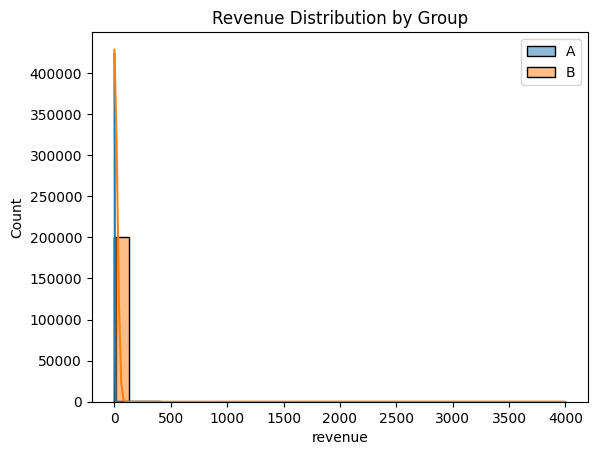

In [221]:
sns.histplot(filtered_a_data['revenue'], label='A', kde=True, bins=30)
sns.histplot(b_data['revenue'], label='B', kde=True, bins=30)

plt.legend()
plt.title('Revenue Distribution by Group');

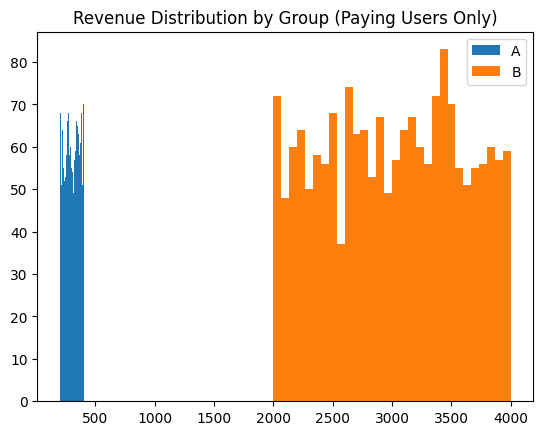

In [222]:
plt.hist(filtered_a_data[filtered_a_data.revenue > 0]['revenue'], label='A', bins=30)
plt.hist(b_data[b_data.revenue > 0]['revenue'], label='B', bins=30)

plt.legend()
plt.title('Revenue Distribution by Group (Paying Users Only)');

#### Initial Data Exploration Results

A preliminary review was conducted on the `ab_data` table, which contains three columns:

- `user_id` - unique user identifier  
  • Type: `int64`  
  • Unique values: 404,770  
  • No missing values  

- `revenue` - user revenue amount  
  • Type: `int64`  
  • Total values: 404,770  
  • No missing values  

- `testgroup` - group assignment (A or B)  
  • Type: `object`  
  • Unique values: 404,770  
  • No missing values  

**Group Statistics:**

🅰️ Group A  
- Total users: 202,103  
- Paying users: 1,928  
- A significant outlier was detected:  
  • 123 users generated **8.5× more revenue** than the combined total from the other 1,805.  
  • Most paying users fall within a revenue range of **200-400**.  
  • Outlier values range from **37,293 to 37,433**.

🅱️ Group B  
- Total users: 202,667  
- Paying users: 1,805  
- Revenue distribution is more homogeneous: primarily in the **2,000-4,000** range.

**Conclusion:**

The dataset is generally clean and suitable for analysis.  
However, the extreme outliers in Group A require special attention.  
Some individual transactions show average receipts **10-100× higher** than the norm, which may skew comparison results.  
It is recommended to either analyze the data both with and without outliers, or request context from the product team.

### 2. Verifying Consistency Between Task Description and Logged Data

Let's validate the accuracy of the three key claims stated in the task context:

1. **Number of users in each group**
   - Control group (A): **202,103** users  
   - Test group (B): **202,667** users

2. **Number of paying users**
   - Group A: **1,928** paying users  
   - Group B: **1,805** paying users

3. **ARPU comparison**
   - Calculation:
     - ARPU(A) = total_revenue_A / total_users_A  
     - ARPU(B) = total_revenue_B / total_users_B  
   - We'll check whether ARPU in group B is indeed approximately **5% higher**, as stated.

In [223]:
# Calculate the total number of users in each group
ab_data.groupby('testgroup').agg({'user_id': 'count'})

,user_id
testgroup,
a,202103
b,202667


In [224]:
# Create a new column indicating whether the user is a paying customer
ab_data['has_paid'] = np.where(ab_data['revenue'] > 0, 1, 0)
ab_data.head()

,user_id,revenue,testgroup,has_paid
0,1,0,b,0
1,2,0,a,0
2,3,0,a,0
3,4,0,b,0
4,5,0,b,0


In [225]:
# Calculate the number of paying users in each group
ab_data.groupby('testgroup').agg({'has_paid': 'sum'})

,has_paid
testgroup,
a,1928
b,1805


In [226]:
# Calculate ARPU
arpu_group = ab_data \
    .groupby('testgroup') \
    .agg(ARPU=('revenue', 'mean'))

In [227]:
# Calculate the ARPU difference between the two groups (as a percentage)
((arpu_group.ARPU['b'] / arpu_group.ARPU['a'] - 1) * 100).round(2)

np.float64(5.26)

#### Verification of Task Assumptions

All three claims stated in the task description are fully confirmed:

- Number of users:  
  — Control group `A`: **202,103**  
  — Test group `B`: **202,667**

- Number of paying users:  
  — Group `A`: **1,928**  
  — Group `B`: **1,805**

- ARPU:  
  — ARPU in group `B` is indeed **5.26% higher** than in group `A`  
  — This figure appears to have been rounded in the original task description

**Conclusion:**  
Based on the data, we can confidently confirm that group `A` is the control group and group `B` is the test group.

### 3. Working with Metrics  
#### Defining the Key Metric

**Growth Metrics:**
- **Paying Users** - the number of users who made at least one purchase. This metric reflects the success of converting users into paying customers.
- **Total Revenue** - the total revenue generated by all users. It shows the overall financial impact of the product.

**Product Metrics:**
- **ARPU (Average Revenue Per User)** - the average revenue per user, including both paying and non-paying users. It provides insight into the overall monetization efficiency.
- **ARPPU (Average Revenue Per Paying User)** - the average revenue per paying user. This metric highlights how much a paying user spends on average and helps evaluate the value of engaged customers.
- **Paying Share** - the share of paying users among all users. This metric helps assess conversion to payment and user motivation to purchase.

**Primary Focus: ARPU**  
ARPU is chosen as the key metric because it reflects the average revenue generated per user from the incoming traffic.  
It includes both paying and non-paying users, offering a balanced view of monetization performance and product effectiveness at scale.

#### Anomaly Check in the Data

Before analyzing the metrics, it's essential to verify data integrity.  
In group A, unusually high revenue values were detected, which could distort the results.

**Approach:**
- No business feedback available → clarification path is not an option.
- Proceeding with outlier analysis.

In the initial step, a visual threshold was identified — values above this line are considered potential outliers.  
A total of **123 such observations** were found.

Next, we’ll apply **Z-transformation** to objectively detect and filter anomalies.

In [228]:
# Add a column with calculated Z-scores
a_data.loc[:, 'zscore'] = zscore(a_data['revenue'])

# Set the threshold for Z-score
z_threshold = 3

# Identify outliers based on Z-score and add a flag column
a_data.loc[:, 'is_outlier_zscore'] = a_data['zscore'].abs() > z_threshold

/var/folders/p9/wtnjbp3d7bgg8v88dg9w0x9r0000gp/T/ipykernel_32064/1241811091.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a_data.loc[:, 'zscore'] = zscore(a_data['revenue'])
/var/folders/p9/wtnjbp3d7bgg8v88dg9w0x9r0000gp/T/ipykernel_32064/1241811091.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a_data.loc[:, 'is_outlier_zscore'] = a_data['zscore'].abs() > z_threshold


In [229]:
# View descriptive statistics for revenue values flagged as outliers
a_data.loc[a_data['is_outlier_zscore'], 'revenue'].describe()

count      123.000000
mean     37319.121951
std         25.442183
min      37293.000000
25%      37301.000000
50%      37311.000000
75%      37329.000000
max      37433.000000
Name: revenue, dtype: float64

##### Outlier Analysis Results

Our assumption was confirmed: the values visually identified as anomalies turned out to be statistical outliers.  
A total of **123 such observations** were detected.

These data points significantly exceed the normal range and distort key metrics — especially **ARPU** and **total revenue** — in group A.

#### Filter outliers in group A and calculate metrics

In [230]:
# Prepare a combined dataset
# Merge the left side of group A's revenue distribution with all of group B's data
ab_data_filtered = pd.merge(b_data, filtered_a_data, how='outer')
ab_data_filtered.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [231]:
# Create a table with key metrics
metrics_filtered = ab_data_filtered \
    .groupby('testgroup') \
    .agg(
        total_users=('user_id', 'count'),
        paid_users=('revenue', lambda x: (x > 0).sum()),
        total_revenue=('revenue', 'sum'),
        ARPU=('revenue', 'mean')
    ) \
    .round(2)

In [232]:
# Calculate ARPPU and add it to the metrics table
metrics_filtered['ARPPU'] = round(metrics_filtered.total_revenue / metrics_filtered.paid_users, 2)

In [233]:
# Calculate the share of paying users and add it to the metrics table
metrics_filtered['paying_share'] = round(metrics_filtered.paid_users / metrics_filtered.total_users * 100, 2)

In [234]:
# Display all calculated metrics
metrics_filtered

,total_users,paid_users,total_revenue,ARPU,ARPPU,paying_share
testgroup,,,,,,
a,201980,1805,545937,2.70,302.46,0.89
b,202667,1805,5421603,26.75,3003.66,0.89


In [235]:
# Calculate the difference in the target metric (ARPU) between the groups
(metrics_filtered['ARPU']['b'] / metrics_filtered['ARPU']['a'] - 1) * 100

np.float64(890.7407407407406)

#### Metrics Summary and Conclusion

Despite having a similar number of paying users and comparable paying share in groups `A` and `B`, group `B` shows significantly stronger financial performance:

- **ARPU (target metric):** `26.75` vs. `2.7`  
- **Total revenue:** `5 421 603` vs. `545 937`  
- **ARPPU:** `3 003.66` vs. `302.46`

The **10x difference** across key business metrics clearly indicates the superiority of the promotional offers tested in group `B`.

These differences are so substantial that running additional statistical tests is **not required**.  
From a business perspective, the gap is large enough to be considered **practically significant** on its own.

**Key Insights:**  
- Group `B`, which received the alternative promotional offers, demonstrates a clear advantage across all core metrics.  
- Even with the same number of paying users, it generates **significantly more revenue**.  
- No further statistical testing is needed, as the observed difference holds **strong business relevance** and confidently supports a decision in favor of the offers used in group `B`.

### Overall Summary of the A/B Test on Promotional Offers

In this analysis, we examined user behavior and revenue performance across two experimental groups:  
Group `A` (control) and Group `B` (test). The key findings are as follows:

- A **large share of users generated zero revenue** in both groups, which distorts the perceived effectiveness of the offers — especially when analyzing metrics like ARPU.
- **Group `A` contained strong outliers**: 123 users generated revenue **8.5 times higher** than the rest of the paying users. These extreme values skewed the averages and made it difficult to interpret the data reliably.
- To improve the accuracy of the analysis, we applied **Z-score filtering** and removed statistical outliers to obtain cleaner, more reliable metrics.

#### Key Takeaways:
- The number and share of paying users were nearly identical between groups `A` and `B`.
- After removing outliers, **ARPU in group `B` reached 26.75**, compared to just 2.7 in group `A` — **nearly 10× higher**.
- Group `B` also significantly outperformed in terms of **total revenue** and **ARPPU** (`3,003.66` vs. `302.46`).
- **ARPU** was selected as the primary metric, as it includes all users and reflects the overall monetization efficiency of the product.

#### Final Conclusion:
- The differences between groups `A` and `B` are **so substantial** that additional statistical testing is unnecessary.  
- **From a business standpoint**, the impact of the promotional offers in group `B` is both clear and compelling.
- We recommend relying on the **outlier-filtered dataset** for decision-making, as it more accurately reflects user behavior and supports better product insights.
- The promotional strategy tested in group `B` demonstrates **superior monetization performance** and can be confidently recommended for broader rollout to other user segments.

### Task 3 - Event Performance Metrics

**Define KPIs to assess the success of the "Plants & Gardens" in-game event, considering both standard and penalty-based variations. Focus on engagement, reward acquisition, and user progression.**

**Context:**  
Each month, the game hosts a themed event where players:
- progress through a series of levels within a limited time window;
- earn unique rewards such as items, coins, and bonuses.

In one specific version of the event, a more challenging mechanic was introduced - _If a player fails to complete a level, they are pushed back several levels as a penalty._

**Key Questions:**
- What **key performance indicators (KPIs)** can objectively measure the success of the event?
- How might these KPIs change if a **failure penalty mechanic** is introduced?

#### Event Evaluation: Approach and Metrics

When evaluating in-game events, many metrics can be used, but it's important to begin by defining the goals.  
Since events are a game design tool that also impacts business outcomes, their key objectives usually include:

- Retaining and re-engaging players  
- Increasing engagement  
- Growing revenue  
Accordingly, metrics can be grouped into three priority levels.

---

**1st Priority: Retention Metrics**  
These metrics help assess whether the event influences player return rates:

- **Event Retention** - shows how long players continue participating in the event after starting.  
- **Post-Event Retention** - indicates whether players stay active in the game after the event ends, reflecting long-term loyalty.

**2nd Priority: Engagement Metrics**  
These evaluate player interest and event completion:

- **Event Participation Rate** - the percentage of players who participated. A high rate indicates strong appeal.  
- **Event Completion Rate** - the percentage of players who completed the event. Helps assess the difficulty balance.

**3rd Priority: Monetization Metrics**  
Financial indicators reflecting the event's commercial success:

- **Total Revenue** - total revenue generated during the event.  
- **ARPU (Average Revenue Per User)** - average revenue per participant, including non-paying users.

---

**Accounting for Mechanic Changes: Penalty Mode**  
If a new mechanic is introduced (e.g., rollback on failure), it's important to track **operational metrics** that help identify pain points and balance issues:

- **Number of retries** - an increase may indicate excessive difficulty.  
- **Average time to complete** - longer time may reduce engagement and increase fatigue.  
- **Conversion to purchases** - difficulty may boost purchases, but should not frustrate players.  
- **Drop-off Rate** - higher drop-offs signal frustration or overload.

---

##### Conclusion  
Event evaluation should include:
- **Core metrics** - applicable across all events, enabling cross-event comparison.  
- **Additional operational metrics** - useful when mechanics change, helping assess the impact of new elements.

This approach ensures an **objective and flexible evaluation system**, aligned with retention, engagement, and business goals.